In [ ]:
import torch
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np

#inception = models.inception_v3(pretrained=True)#API anterior
inception = models.inception_v3(weights='DEFAULT')#API anterior

print(inception)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:03<00:00, 36.2MB/s] 


Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [ ]:
from torchvision import transforms
transform = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224),  transforms.ToTensor(),
 transforms.Normalize( mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

from PIL import Image
imgs=["https://learnopencv.com/wp-content/uploads/2019/05/dog.jpg",
"https://learnopencv.com/wp-content/uploads/2021/01/strawberries.jpg",
"https://learnopencv.com/wp-content/uploads/2021/01/automotive.jpg",
"https://learnopencv.com/wp-content/uploads/2021/06/Getting_Started_with_Opencv.jpg",
"https://learnopencv.com/wp-content/uploads/2021/06/sample.jpg"]

img=[]
for im in imgs:
  !wget $im -q
  name=im.split('/')[-1]
  img.append(Image.open(name))

In [ ]:
import pandas as pd
dic=pd.read_csv('https://robertohincapie.com/data/imagenet_dict.txt', sep=':', header=None)
dic.columns=['indice','clase']
clases={}
for i in range(len(dic)):
  cad=dic.iloc[i]['clase']
  cad=cad[0:-2]
  cad=cad.replace('\'','')
  clases[dic.iloc[i]['indice']]=cad

torch.Size([5, 3, 224, 224])
torch.Size([5, 1000])


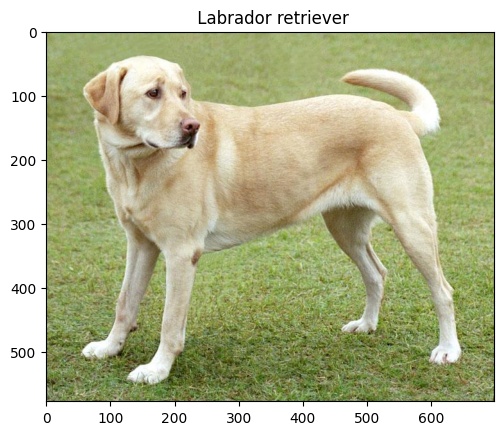

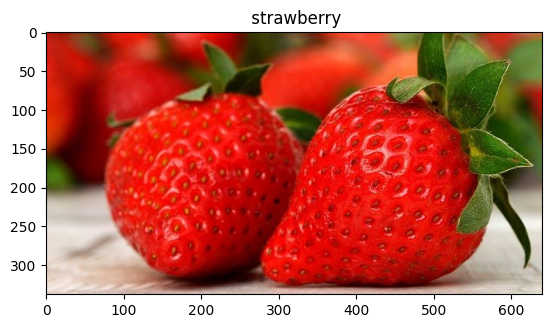

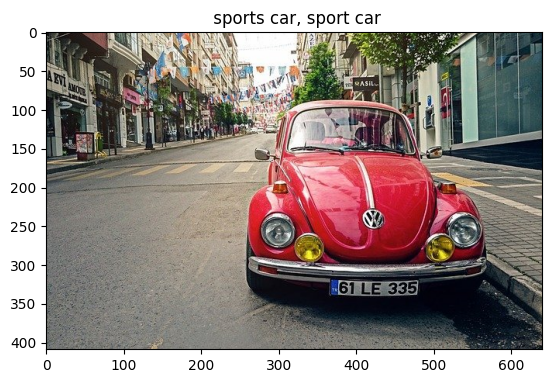

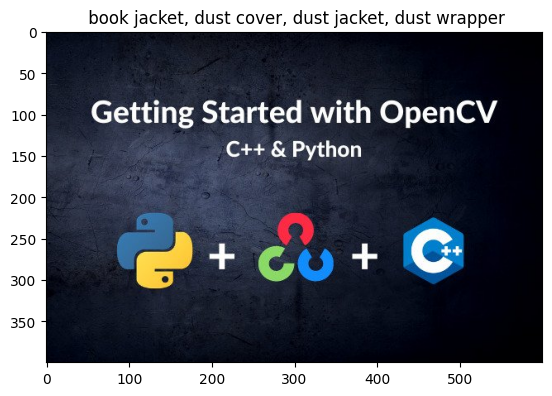

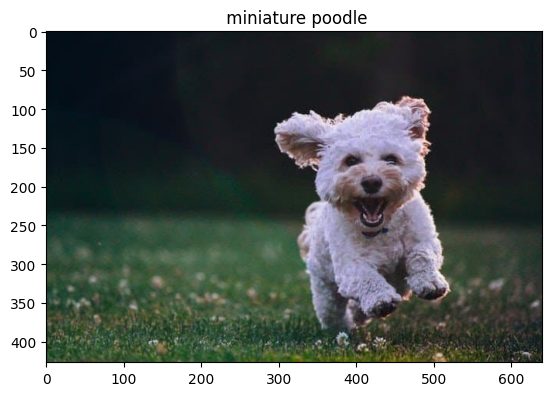

In [ ]:
batch_t=torch.cat([torch.unsqueeze(transform(im),0) for im in img], axis=0)
print(batch_t.shape)
inception.eval()
out = inception(batch_t)
print(out.shape)

_, index = torch.max(out, 1)
index=index.numpy()
i=0
for ind in index:
  plt.figure()
  plt.imshow(img[i])
  plt.title(clases[ind])
  i+=1
